# Day 03: 池化 —— 信息的浓缩与抽象

> 👁️ 第三周 · 视觉的征服与深度的瓶颈 · 第 3 天

昨天我们学习了卷积层如何提取特征。但有一个问题：

每次卷积后，特征图的尺寸基本不变，而一张 224x224 的图片经过几层卷积后，还是差不多大——计算量爆炸，而且特征太密集，难以理解。

**解决方案**：池化（Pooling）——把相邻的小区域「浓缩」成单个值。

类比：看一张大地图时，你会缩小比例尺，把 100x100 个像素浓缩成 1 个点——「这里有一片森林」。

**今日任务**：理解最大池化和平均池化，用代码演示池化如何压缩信息。

---

## 1. 池化的核心思想

池化（Pooling）= 对局部区域做「压缩汇总」

类比：
- **最大池化** = 选「最吵的那个声音」
  - 把局部区域里最显著的特征留下
  - 就像在一群人里只记住嗓门最大的那个

- **平均池化** = 选「平均水平」
  - 把局部区域的平均值作为代表
  - 就像学生评分：去掉最高分和最低分，取平均值

```
输入 (4x4) → 2x2 池化窗口 → 输出 (2x2)

┌───┬───┬───┬───┐     ┌─────┬─────┐
│ 1 │ 5 │ 3 │ 7 │     │  6  │  8  │
├───┼───┼───┼───┤  →  │ max │ max │
│ 2 │ 6 │ 4 │ 8 │     │  6  │  8  │
├───┼───┼───┼───┤     └─────┴─────┘
│ 0 │ 3 │ 2 │ 1 │
└───┴───┴───┴───┘
```

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 创建一张测试图片
image = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
    [9.0, 10.0, 11.0, 12.0],
    [13.0, 14.0, 15.0, 16.0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1, 1, 4, 4]

print("输入图片 (1x1x4x4)：")
print(image.squeeze())
print("\n每个 2x2 窗口会浓缩成 1 个值")

输入图片 (1x1x4x4)：
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

每个 2x2 窗口会浓缩成 1 个值


In [2]:
# 最大池化
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
max_result = max_pool(image)

print("最大池化结果 (MaxPool2d)：")
print(max_result.squeeze())
print("\n解读：")
print("  左上窗口 [1,2,5,6] → 最大值 = 6")
print("  右上窗口 [3,4,7,8] → 最大值 = 8")
print("  ...以此类推")

最大池化结果 (MaxPool2d)：
tensor([[ 6.,  8.],
        [14., 16.]])

解读：
  左上窗口 [1,2,5,6] → 最大值 = 6
  右上窗口 [3,4,7,8] → 最大值 = 8
  ...以此类推


In [3]:
# 平均池化
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
avg_result = avg_pool(image)

print("平均池化结果 (AvgPool2d)：")
print(avg_result.squeeze())
print("\n解读：")
print("  左上窗口 [1,2,5,6] → 平均值 = (1+2+5+6)/4 = 3.5")
print("  右上窗口 [3,4,7,8] → 平均值 = (3+4+7+8)/4 = 5.5")
print("  ...以此类推")

平均池化结果 (AvgPool2d)：
tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])

解读：
  左上窗口 [1,2,5,6] → 平均值 = (1+2+5+6)/4 = 3.5
  右上窗口 [3,4,7,8] → 平均值 = (3+4+7+8)/4 = 5.5
  ...以此类推


---

## 2. 可视化池化过程

让我们用实际图片演示池化的效果。

「有纹理」的图片：


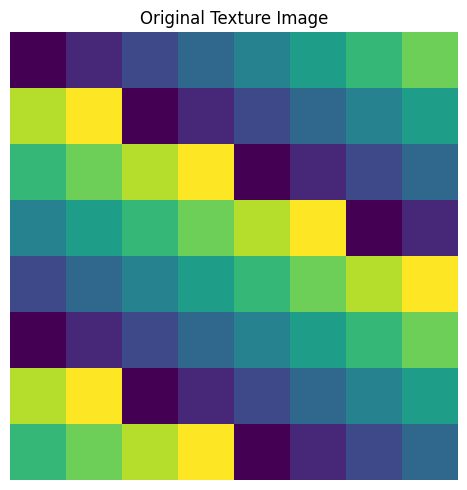

In [4]:
# 创建一个「有纹理」的图片
def create_texture_image(size=8):
    """创建一个有纹理的图片"""
    img = torch.zeros(size, size)
    for i in range(size):
        for j in range(size):
            img[i, j] = (i * size + j) % 10  # 模拟纹理
    return img

texture = create_texture_image(8)

print("「有纹理」的图片：")
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(texture.numpy(), cmap='viridis')
ax.set_title('Original Texture Image')
ax.axis('off')
plt.tight_layout()
plt.savefig('images/cnn_day03_original_texture.png', dpi=150)
plt.show()

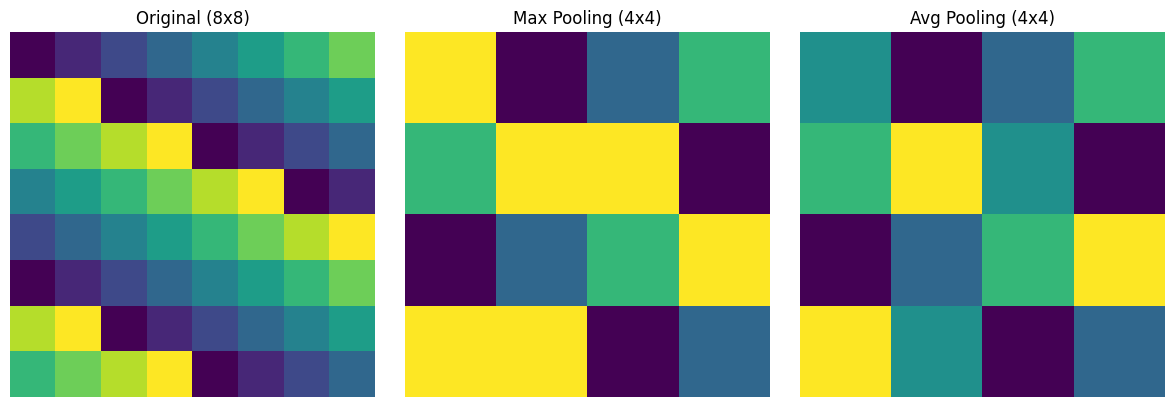


对比：
  Max Pooling: 保留最显著的特征（最亮的点）
  Avg Pooling: 保留平滑的平均特征

两者都将图片从 8x8 压缩到 4x4，减少了 75% 的计算量！


In [5]:
# 应用不同池化
texture_batch = texture.unsqueeze(0).unsqueeze(0)  # [1, 1, 8, 8]

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

max_out = max_pool(texture_batch).squeeze()
avg_out = avg_pool(texture_batch).squeeze()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(texture.numpy(), cmap='viridis')
axes[0].set_title('Original (8x8)')
axes[0].axis('off')

axes[1].imshow(max_out.numpy(), cmap='viridis')
axes[1].set_title('Max Pooling (4x4)')
axes[1].axis('off')

axes[2].imshow(avg_out.numpy(), cmap='viridis')
axes[2].set_title('Avg Pooling (4x4)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('images/cnn_day03_pooling_comparison.png', dpi=150)
plt.show()

print("\n对比：")
print("  Max Pooling: 保留最显著的特征（最亮的点）")
print("  Avg Pooling: 保留平滑的平均特征")
print("\n两者都将图片从 8x8 压缩到 4x4，减少了 75% 的计算量！")

---

## 3. 池化的两大优势

池化不仅仅是「压缩」，它还有两个关键作用：

In [6]:
print("优势1: 减少过拟合（减少参数数量）")
print("-"*50)
print("\n假设输入是 100x100 = 10000 个像素")
print("不做池化：下一层需要处理 10000 个输入")
print("2x2 池化后：变成 50x50 = 2500 个输入")
print("参数减少 75%！")

print("\n" + "="*50)
print("优势2: 提供平移不变性")
print("-"*50)

# 模拟「平移」
img1 = torch.zeros(8, 8)
img1[2:4, 3:5] = 1.0  # 一个方块在位置A

img2 = torch.zeros(8, 8)
img2[4:6, 5:7] = 1.0  # 同样的方块在位置B（平移了）

# 2x2 最大池化
pool = nn.MaxPool2d(2, stride=2)

out1 = pool(img1.unsqueeze(0).unsqueeze(0)).squeeze()
out2 = pool(img2.unsqueeze(0).unsqueeze(0)).squeeze()

print("\n方块在位置A的特征图：")
print(out1)
print("\n方块在位置B的特征图：")
print(out2)
print("\n虽然原始位置不同，但池化后的特征图更相似了！")
print("这就是「平移不变性」——物体移动后，网络还能认出它。")

优势1: 减少过拟合（减少参数数量）
--------------------------------------------------

假设输入是 100x100 = 10000 个像素
不做池化：下一层需要处理 10000 个输入
2x2 池化后：变成 50x50 = 2500 个输入
参数减少 75%！

优势2: 提供平移不变性
--------------------------------------------------

方块在位置A的特征图：
tensor([[0., 0., 0., 0.],
        [0., 1., 1., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

方块在位置B的特征图：
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 0., 0.]])

虽然原始位置不同，但池化后的特征图更相似了！
这就是「平移不变性」——物体移动后，网络还能认出它。


---

## 4. 全局池化：另一种池化策略

除了局部池化，还有一种「全局池化」——把整个特征图浓缩成单个值。

类比：读完一整本书，只记住一个词：「精彩」。

In [7]:
# 全局平均池化
global_avg = nn.AdaptiveAvgPool2d((1, 1))
global_max = nn.AdaptiveMaxPool2d((1, 1))

feature_map = torch.randn(1, 8, 4, 4)  # 模拟一个有 8 个通道的特征图

gavg = global_avg(feature_map)
gmax = global_max(feature_map)

print("输入特征图尺寸:", feature_map.shape)
print("全局平均池化后:", gavg.shape, "-> 每个通道的平均值")
print("全局最大池化后:", gmax.shape, "-> 每个通道的最大值")
print("\n解读：GlobalAvgPool 把每个通道压缩成 1 个数")
print("  输出 [1, 8, 1, 1] 意味着 8 个通道各产生 1 个汇总值")

输入特征图尺寸: torch.Size([1, 8, 4, 4])
全局平均池化后: torch.Size([1, 8, 1, 1]) -> 每个通道的平均值
全局最大池化后: torch.Size([1, 8, 1, 1]) -> 每个通道的最大值

解读：GlobalAvgPool 把每个通道压缩成 1 个数
  输出 [1, 8, 1, 1] 意味着 8 个通道各产生 1 个汇总值


---

## 今日总结

| 概念 | 直觉理解 |
|------|----------|
| 最大池化 | 只记住「最吵的那个」——保留最显著的特征 |
| 平均池化 | 取「平均水平」——平滑、鲁棒 |
| 2x2 池化 | 把 4 个像素变成 1 个，减少 75% 计算量 |
| 平移不变性 | 物体稍微移动，特征图变化不大 |
| 全局池化 | 把整张图浓缩成 1 个数，像「图片摘要」 |

**卷积 + 池化的经典组合**：
```
输入图片
  → Conv（提取特征）
  → ReLU（激活）
  → Pool（压缩）
  → ... 重复几层 ...
  → Global Pool（汇总）
  → FC（分类）
```

**明日预告**：今天学习了 CNN 的核心组件。明天把它们组合起来，构建一个完整的 **LeNet-5**——第一个商用的卷积神经网络！